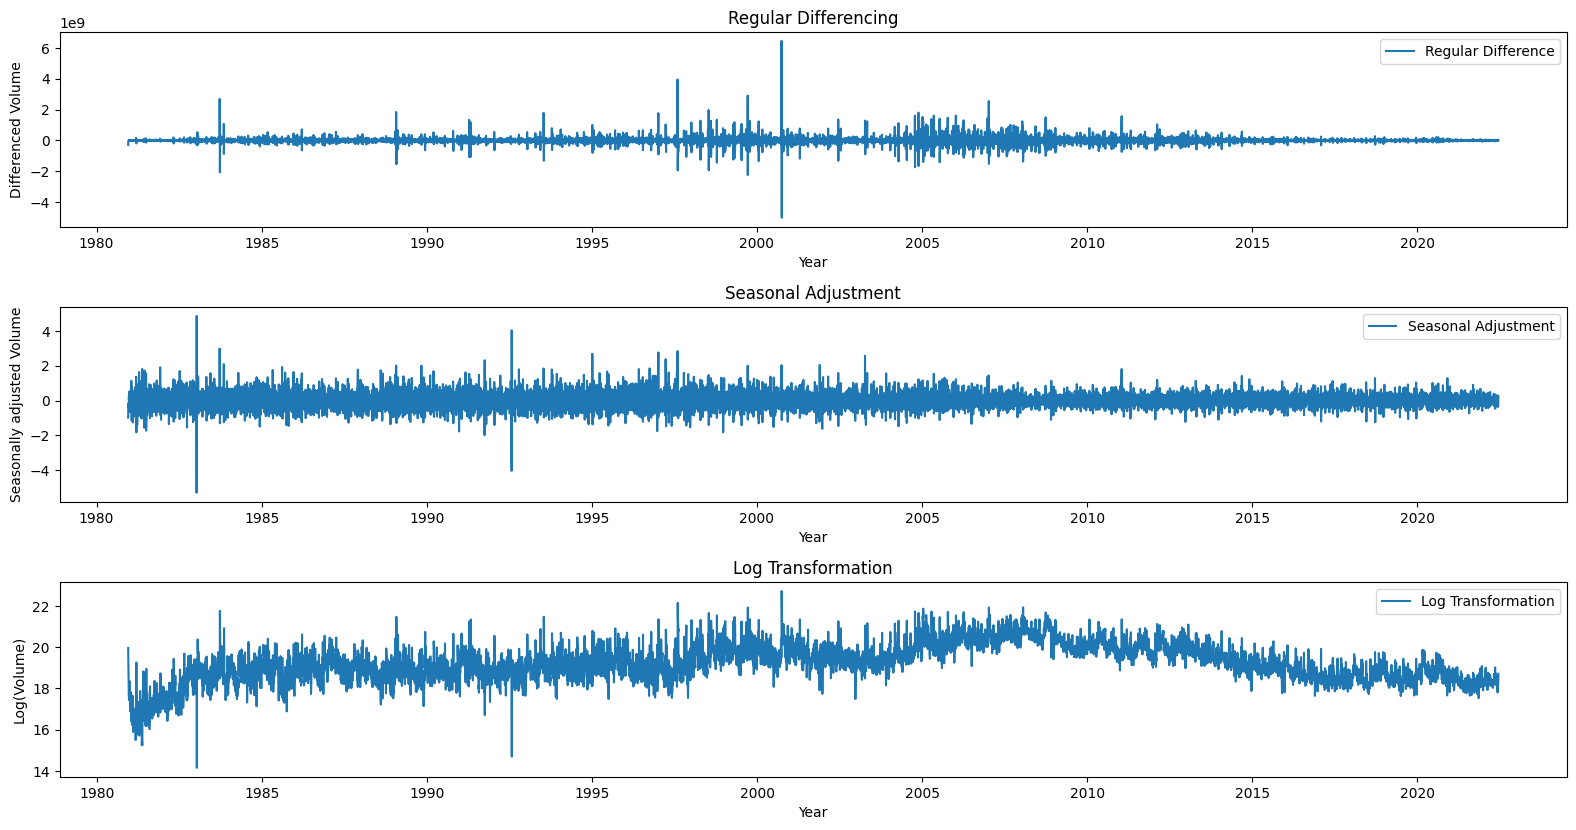

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


data = pd.read_csv('apple.csv', parse_dates=['Date'])
data.set_index('Date', inplace=True)

data['volume_diff'] = data['Volume'].diff()
data['volume_log'] = data['Volume'].apply(lambda x: np.log(x) if x > 0 else np.nan)
data['volume_log_diff'] = data['volume_log'].diff()

data['volume_sea_diff'] = seasonal_decompose(data['Volume'], model='additive', period=12).residcleaned_volume_log_diff = data['volume_log_diff'].dropna()
if len(cleaned_volume_log_diff) >= 2 * 12:
    data['volume_log_seasonal_diff'] = seasonal_decompose(
        cleaned_volume_log_diff, model='additive', period=12
    ).resid
else:
    print("Warning: Not enough data for seasonal decomposition after cleaning 'volume_log_diff'.")
    data['volume_log_seasonal_diff'] = pd.Series(index=data.index, dtype=float)


plt.figure(figsize=(16, 16))

plt.subplot(6, 1, 2)
plt.plot(data['volume_diff'], label='Regular Difference')
plt.title('Regular Differencing')
plt.xlabel('Year')
plt.ylabel('Differenced Volume')
plt.legend()
print()
plt.subplot(6, 1, 3)
plt.plot(data['volume_sea_diff'], label='Seasonal Adjustment')
plt.title('Seasonal Adjustment')
plt.xlabel('Year')
plt.ylabel('Seasonally adjusted Volume')
plt.legend()
print()
plt.subplot(6, 1, 4)
plt.plot(data['volume_log'], label='Log Transformation')
plt.title('Log Transformation')
plt.xlabel('Year')
plt.ylabel('Log(Volume)')
plt.legend()

plt.tight_layout()
plt.show()